# Final Paper Results Synthesis

This notebook consolidates the accepted result chain:

- Phase 1 original in-distribution leaderboard.
- Phase 1 grouped cross-validation.
- Phase 1 ablation and PINN-feature hybrid evidence.
- Phase 4 raw external-transfer failure.
- Phase 4d normalized external-transfer fix.
- Phase 4g calibration-assisted adaptation.

Attach the previous output zips as Kaggle inputs when possible. The notebook
also contains fallback values from the verified runs so it remains executable
if a zip is omitted.


In [90]:
import json
import re
import zipfile
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    display = print

KAGGLE_INPUT = Path("/kaggle/input")
WORKING = Path("/kaggle/working")
if not KAGGLE_INPUT.exists():
    KAGGLE_INPUT = Path(".")
    WORKING = Path(".")

RUN_TAG = "final_paper_results_synthesis_" + datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = WORKING / RUN_TAG
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Run tag:", RUN_TAG)
print("Input root:", KAGGLE_INPUT)
print("Output:", OUT_DIR)


Run tag: final_paper_results_synthesis_20260625_103238
Input root: /kaggle/input
Output: /kaggle/working/final_paper_results_synthesis_20260625_103238


## 1. Helpers


In [91]:
def print_section(title):
    print("\n" + "=" * 88)
    print(title)
    print("=" * 88)


def search_roots():
    roots = [KAGGLE_INPUT, WORKING, Path(".")]
    extra = [Path("/kaggle/input/datasets"), Path("/kaggle/working")]
    return [p for p in roots + extra if p.exists()]


def read_csv_anywhere(filename, required=False):
    """Read a CSV directly or from any zip below Kaggle/local roots."""
    for root in search_roots():
        direct = list(root.rglob(filename))
        for p in direct:
            if p.is_file():
                print(f"{filename}: {p}")
                return pd.read_csv(p), str(p)

    for root in search_roots():
        for zp in root.rglob("*.zip"):
            try:
                with zipfile.ZipFile(zp) as z:
                    names = z.namelist()
                    matches = [n for n in names if Path(n).name == filename]
                    if matches:
                        with z.open(matches[0]) as f:
                            print(f"{filename}: {zp}!{matches[0]}")
                            return pd.read_csv(f), f"{zp}!{matches[0]}"
            except Exception:
                continue

    if required:
        raise FileNotFoundError(filename)
    print(f"{filename}: not found; using fallback if available")
    return None, None


def savefig(name):
    path = OUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight", dpi=260)
    print("Saved:", path)


plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 260,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## 2. Load Phase 1 Final Synthesis


In [92]:
phase1_claims, src_phase1_claims = read_csv_anywhere("table_paper_claims_summary.csv")
phase1_cv, src_phase1_cv = read_csv_anywhere("table_grouped_cv.csv")
phase1_hybrid, src_phase1_hybrid = read_csv_anywhere("table_hybrid_pinn_feature_results.csv")
phase1_original, src_phase1_original = read_csv_anywhere("table_original_phase1_leaderboard.csv")
phase1_ablation, src_phase1_ablation = read_csv_anywhere("table_ablation_best_by_protocol.csv")

if phase1_claims is None:
    phase1_claims = pd.DataFrame([
        {
            "Claim": "Best original deployment-realistic model",
            "Evidence": "Original Phase 1 leaderboard",
            "Model": "LSTM v4 rollout tuned",
            "Metric": "Test macro MAPE",
            "Value": "1.551",
            "Interpretation": "Primary in-distribution headline.",
        },
        {
            "Claim": "Best grouped-CV deployment model",
            "Evidence": "5-fold cell-grouped CV",
            "Model": "LSTM_main_full9_rollout",
            "Metric": "CV macro MAPE mean +/- std",
            "Value": "1.627 +/- 0.724",
            "Interpretation": "Grouped CV supports LSTM rollout robustness.",
        },
        {
            "Claim": "Best PINN-feature hybrid fixed-split result",
            "Evidence": "Phase 6/7 hybrid experiments",
            "Model": "PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress",
            "Metric": "Test macro MAPE",
            "Value": "1.638",
            "Interpretation": "PINN-derived descriptors help sparse LSTM.",
        },
    ])

if phase1_cv is None:
    phase1_cv = pd.DataFrame([
        {"Rank": 1, "variant": "LSTM_main_full9_teacher_forced", "protocol": "teacher_forced", "mean_MAPE": 1.454544, "std_MAPE": 0.745727, "mean_R2": 0.951842},
        {"Rank": 2, "variant": "LSTM_main_full9_rollout", "protocol": "autoregressive_rollout", "mean_MAPE": 1.626968, "std_MAPE": 0.724439, "mean_R2": 0.940112},
        {"Rank": 3, "variant": "LSTM_sparse_k_Re0_rollout", "protocol": "autoregressive_rollout", "mean_MAPE": 1.879669, "std_MAPE": 0.686698, "mean_R2": 0.893283},
        {"Rank": 4, "variant": "PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress_rollout", "protocol": "autoregressive_rollout", "mean_MAPE": 2.087658, "std_MAPE": 0.657624, "mean_R2": 0.888276},
        {"Rank": 6, "variant": "PINN_pred_full9", "protocol": "pointwise", "mean_MAPE": 7.560410, "std_MAPE": 0.195151, "mean_R2": 0.391743},
        {"Rank": 7, "variant": "PINN_phys_full9", "protocol": "pointwise", "mean_MAPE": 8.048746, "std_MAPE": 0.294153, "mean_R2": 0.351841},
    ])

if phase1_hybrid is None:
    phase1_hybrid = pd.DataFrame([
        {"Rank": 1, "model": "PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress", "MAPE": 1.638201, "R2": 0.915776},
        {"Rank": 2, "model": "PINNfeat_sparse_k_Re0_Q0_EaStress", "MAPE": 1.783867, "R2": 0.910315},
    ])

print_section("Phase 1 Claims")
display(phase1_claims)


table_paper_claims_summary.csv: /kaggle/working/phase1f_paper_ready_synthesis_20260625_092740/table_paper_claims_summary.csv
table_grouped_cv.csv: /kaggle/working/phase1f_paper_ready_synthesis_20260625_092740/table_grouped_cv.csv
table_hybrid_pinn_feature_results.csv: /kaggle/working/phase1f_paper_ready_synthesis_20260625_092740/table_hybrid_pinn_feature_results.csv
table_original_phase1_leaderboard.csv: /kaggle/working/phase1f_paper_ready_synthesis_20260625_092516/table_original_phase1_leaderboard.csv
table_ablation_best_by_protocol.csv: /kaggle/working/phase1f_paper_ready_synthesis_20260625_092740/table_ablation_best_by_protocol.csv

Phase 1 Claims


,Claim,Evidence,Model,Metric,Value,Interpretation
0,Best original deployment-realistic model,Original Phase 1 leaderboard,LSTM v4 rollout tuned,Test macro MAPE,1.551,Primary in-distribution headline.
1,Best grouped-CV deployment model,5-fold cell-grouped CV,LSTM_main_full9_rollout,CV macro MAPE mean +/- std,1.627 +/- 0.724,Grouped CV supports LSTM rollout robustness.
2,Best PINN-feature hybrid fixed-split result,Phase 6/7 hybrid experiments,PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress,Test macro MAPE,1.638201,"PINN-derived features help sparse LSTM, but do..."
3,Best current ablation result,Current-model ablation,PINNfeat_no_stress,Ablation macro MAPE,1.2359847796430552,Use as relative feature evidence because Full9...


## 3. Load Phase 4 External Results


In [93]:
phase4_raw, src_phase4_raw = read_csv_anywhere("phase4_external_metrics_summary.csv")
phase4d, src_phase4d = read_csv_anywhere("phase4d_paper_normalized_hybrid_external_table.csv")
phase4g, src_phase4g = read_csv_anywhere("phase4g_paper_adaptation_success_table.csv")
phase4e, src_phase4e = read_csv_anywhere("phase4e_fewshot_metrics_summary.csv")
phase4f, src_phase4f = read_csv_anywhere("phase4f_residual_metrics_summary.csv")

if phase4_raw is None:
    phase4_raw = pd.DataFrame([
        {"Model": "PINN_phys_best_external", "Protocol": "frozen_external_pointwise", "Feature_Set": "best corrected Phase 4 variant", "Q_MAPE": 24.10, "Q_R2": np.nan, "source": "prior_corrected_phase4_audit"},
        {"Model": "PINN_phys_full9_external", "Protocol": "frozen_external_pointwise", "Feature_Set": "full9", "Q_MAPE": 29.50, "Q_R2": np.nan, "source": "prior_corrected_phase4_audit"},
        {"Model": "LSTM_v4_sparse_k_Re0_external", "Protocol": "BOL_seeded_autoregressive_rollout", "Feature_Set": "k_exp + Re0", "Q_MAPE": 30.97, "Q_R2": np.nan, "source": "prior_corrected_phase4_audit"},
        {"Model": "LSTM_v4_full9_external", "Protocol": "BOL_seeded_autoregressive_rollout", "Feature_Set": "full9", "Q_MAPE": 37.51, "Q_R2": np.nan, "source": "prior_corrected_phase4_audit"},
    ])

if phase4d is None:
    phase4d = pd.DataFrame([
        {"Model": "NormSOH_PINNfeat_LSTM", "Protocol": "BOL_seeded_rollout_restored", "Split": "Kirkaldy_external", "Target": "Q", "MAPE": 5.206538, "MAE": 0.215096, "RMSE": 0.263145, "R2": -0.020178, "n": 120, "n_cells": 8},
        {"Model": "NormSOH_LSTM_base", "Protocol": "BOL_seeded_rollout_restored", "Split": "Kirkaldy_external", "Target": "Q", "MAPE": 6.082495, "MAE": 0.240960, "RMSE": 0.291148, "R2": -0.248865, "n": 120, "n_cells": 8},
        {"Model": "NormSOH_PINNfeat_ExtraTrees", "Protocol": "pointwise_external_restored", "Split": "Kirkaldy_external", "Target": "Q", "MAPE": 12.113089, "MAE": 0.482623, "RMSE": 0.553145, "R2": -2.194747, "n": 128, "n_cells": 8},
        {"Model": "BOL_persistence", "Protocol": "no_degradation_baseline_restored", "Split": "Kirkaldy_external", "Target": "Q", "MAPE": 18.443991, "MAE": 0.740459, "RMSE": 0.785804, "R2": -8.097340, "n": 120, "n_cells": 8},
    ])

if phase4g is None:
    phase4g = pd.DataFrame([
        {"Model": "NormSOH_PINNfeat_LSTM_head_only", "Protocol": "first_50pct_restored", "Split": "Kirkaldy_later_rows", "Target": "Q", "MAPE": 3.418669, "MAE": 0.135260, "RMSE": 0.164963, "R2": -0.184861, "n": 64, "n_cells": 8, "n_calibration_rows": 56},
        {"Model": "NormSOH_PINNfeat_LSTM_head_only", "Protocol": "first_40pct_restored", "Split": "Kirkaldy_later_rows", "Target": "Q", "MAPE": 3.749086, "MAE": 0.149868, "RMSE": 0.182011, "R2": -0.312935, "n": 72, "n_cells": 8, "n_calibration_rows": 48},
        {"Model": "NormSOH_PINNfeat_LSTM_head_only", "Protocol": "first_25pct_restored", "Split": "Kirkaldy_later_rows", "Target": "Q", "MAPE": 5.059542, "MAE": 0.208078, "RMSE": 0.250976, "R2": -0.768978, "n": 96, "n_cells": 8, "n_calibration_rows": 24},
    ])

if phase4e is None:
    phase4e = pd.DataFrame([
        {"Model": "NormSOH_PINNfeat_LSTM_finetuned", "Protocol": "first_25pct_restored", "Split": "Kirkaldy_later_rows", "Target": "Q", "MAPE": 11.466504, "n_calibration_rows": 24},
    ])

if phase4f is None:
    phase4f = pd.DataFrame([
        {"Model": "NormSOH_PINNfeat_LSTM_none", "Protocol": "first_25pct_restored", "Split": "Kirkaldy_later_rows", "Target": "Q", "MAPE": 10.932934, "n_calibration_rows": 24},
    ])

print_section("Phase 4d External Table")
display(phase4d[phase4d["Target"].eq("Q")].sort_values("MAPE"))
print_section("Phase 4g Adaptation Table")
display(phase4g[phase4g["Target"].eq("Q")].sort_values("MAPE").head(12))


phase4_external_metrics_summary.csv: /kaggle/working/phase4_paper_ready_external_20260625_093834/phase4_external_metrics_summary.csv
phase4d_paper_normalized_hybrid_external_table.csv: /kaggle/working/phase4d_normalized_pinn_hybrid_external_20260625_095450/phase4d_paper_normalized_hybrid_external_table.csv
phase4g_paper_adaptation_success_table.csv: /kaggle/working/phase4g_adaptation_success_conditions_20260625_102203/phase4g_paper_adaptation_success_table.csv
phase4e_fewshot_metrics_summary.csv: /kaggle/working/phase4e_fewshot_finetune_external_20260625_100253/phase4e_fewshot_metrics_summary.csv
phase4f_residual_metrics_summary.csv: /kaggle/working/phase4f_residual_calibration_external_20260625_101330/phase4f_residual_metrics_summary.csv

Phase 4d External Table


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells,Rank_in_target
0,NormSOH_PINNfeat_LSTM,BOL_seeded_rollout_restored,Kirkaldy_external,Q,5.206538,0.215096,0.263145,-0.020178,120,8,1.0
1,NormSOH_LSTM_base,BOL_seeded_rollout_restored,Kirkaldy_external,Q,6.082495,0.240960,0.291148,-0.248865,120,8,2.0
2,NormSOH_PINNfeat_ExtraTrees,pointwise_external_restored,Kirkaldy_external,Q,12.113089,0.482623,0.553145,-2.194747,128,8,3.0
3,BOL_persistence,no_degradation_baseline_restored,Kirkaldy_external,Q,18.443991,0.740459,0.785804,-8.097340,120,8,4.0



Phase 4g Adaptation Table


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells,n_calibration_rows,Rank_in_target_protocol
77,NormSOH_PINNfeat_LSTM_head_only,first_50pct_restored,Kirkaldy_later_rows,Q,3.418669,0.135260,0.164963,-0.184861,64,8,56,1.0
79,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_50pct_restored,Kirkaldy_later_rows,Q,3.427130,0.135627,0.165370,-0.190703,64,8,56,2.0
61,NormSOH_PINNfeat_LSTM_head_only,first_40pct_restored,Kirkaldy_later_rows,Q,3.749086,0.149868,0.182011,-0.312935,72,8,48,1.0
63,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_40pct_restored,Kirkaldy_later_rows,Q,3.754269,0.150090,0.182270,-0.316673,72,8,48,2.0
45,NormSOH_PINNfeat_LSTM_head_only,first_25pct_restored,Kirkaldy_later_rows,Q,5.059542,0.208078,0.250976,-0.768978,96,8,24,1.0
73,NormSOH_PINNfeat_LSTM_monotonic_per_cell_offset,first_50pct_restored,Kirkaldy_later_rows,Q,5.060770,0.195322,0.225624,-1.216471,64,8,56,3.0
47,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_25pct_restored,Kirkaldy_later_rows,Q,5.090392,0.209391,0.252548,-0.791199,96,8,24,2.0
31,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_3_RPT_restored,Kirkaldy_later_rows,Q,5.514236,0.229103,0.277619,-0.842698,104,8,16,1.0
29,NormSOH_PINNfeat_LSTM_head_only,first_3_RPT_restored,Kirkaldy_later_rows,Q,5.697084,0.236901,0.286650,-0.964526,104,8,16,2.0
57,NormSOH_PINNfeat_LSTM_monotonic_per_cell_offset,first_40pct_restored,Kirkaldy_later_rows,Q,5.708329,0.221148,0.254476,-1.566498,72,8,48,3.0


## 4. Final Manuscript Tables


In [94]:
final_main = pd.DataFrame([
    {
        "Section": "Phase 1 in-distribution",
        "Result": "Deployment-realistic LSTM rollout",
        "Model": "LSTM v4 rollout tuned",
        "Protocol": "fixed split autoregressive rollout",
        "Metric": "macro MAPE [%]",
        "Value": 1.551,
        "Paper_Use": "Main in-distribution performance headline.",
    },
    {
        "Section": "Phase 1 grouped CV",
        "Result": "Grouped-CV LSTM rollout",
        "Model": "LSTM_main_full9_rollout",
        "Protocol": "5-fold cell-grouped autoregressive rollout",
        "Metric": "macro MAPE mean +/- std [%]",
        "Value": "1.627 +/- 0.724",
        "Paper_Use": "Robustness against cell-split leakage.",
    },
    {
        "Section": "Phase 1 hybrid",
        "Result": "Best fixed-split PINN-feature hybrid",
        "Model": "PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress",
        "Protocol": "fixed split autoregressive rollout",
        "Metric": "macro MAPE [%]",
        "Value": 1.638201,
        "Paper_Use": "Physics descriptors improve sparse LSTM inputs.",
    },
    {
        "Section": "Phase 4 raw external",
        "Result": "Raw-capacity external transfer failed",
        "Model": "LSTM_v4_full9_external",
        "Protocol": "raw Q BOL-seeded rollout",
        "Metric": "Q-MAPE [%]",
        "Value": 37.51,
        "Paper_Use": "Motivates capacity normalization under cell-format shift.",
    },
    {
        "Section": "Phase 4 normalized external",
        "Result": "Zero-calibration external transfer fixed",
        "Model": "NormSOH_PINNfeat_LSTM",
        "Protocol": "SOH-normalized BOL-seeded rollout, restored Q",
        "Metric": "Q-MAPE [%]",
        "Value": 5.206538,
        "Paper_Use": "Main external-validation headline.",
    },
    {
        "Section": "Phase 4 calibrated external",
        "Result": "Calibration-assisted later-window forecasting",
        "Model": "NormSOH_PINNfeat_LSTM_head_only",
        "Protocol": "first 40-50% calibration, head-only adaptation",
        "Metric": "later-row Q-MAPE [%]",
        "Value": "3.75-3.42",
        "Paper_Use": "Secondary domain-adaptation result, not zero-calibration claim.",
    },
])
final_main.to_csv(OUT_DIR / "table_final_main_results.csv", index=False)
display(final_main)

# External validation progression
external_progress = pd.DataFrame([
    {"Stage": "Raw LSTM v4 full external", "Model": "LSTM_v4_full9_external", "Protocol": "raw Q rollout", "Q_MAPE": 37.51, "Category": "Failure"},
    {"Stage": "Raw best PINN external", "Model": "PINN_phys_best_external", "Protocol": "raw Q pointwise", "Q_MAPE": 24.10, "Category": "Failure"},
    {"Stage": "BOL persistence", "Model": "BOL_persistence", "Protocol": "no degradation", "Q_MAPE": 18.443991, "Category": "Baseline"},
    {"Stage": "Normalized LSTM", "Model": "NormSOH_LSTM_base", "Protocol": "SOH rollout restored Q", "Q_MAPE": 6.082495, "Category": "Normalized"},
    {"Stage": "Normalized PINN-feature LSTM", "Model": "NormSOH_PINNfeat_LSTM", "Protocol": "SOH rollout restored Q", "Q_MAPE": 5.206538, "Category": "Normalized hybrid"},
])
external_progress.to_csv(OUT_DIR / "table_final_external_progression.csv", index=False)
display(external_progress.sort_values("Q_MAPE"))

# Adaptation table: keep Q rows only, sorted
adapt_q = phase4g[phase4g["Target"].eq("Q")].copy()
adapt_q = adapt_q.sort_values("MAPE").reset_index(drop=True)
adapt_q["Rank"] = np.arange(1, len(adapt_q) + 1)
adapt_q.to_csv(OUT_DIR / "table_final_calibration_assisted_adaptation.csv", index=False)
display(adapt_q.head(15))

# Negative adaptation evidence
negative_adapt = pd.DataFrame([
    {"Experiment": "Phase 4e naive few-shot fine-tuning", "Best_Protocol": "first_25pct", "Best_Q_MAPE": 11.466504, "Interpretation": "Updating sequence-model weights is unstable with sparse early Kirkaldy rows."},
    {"Experiment": "Phase 4f residual calibration", "Best_Protocol": "first_25pct + no correction", "Best_Q_MAPE": 10.932934, "Interpretation": "Early residuals are biased and do not transfer to later degradation."},
    {"Experiment": "Phase 4g constrained adaptation", "Best_Protocol": "first_50pct + head_only", "Best_Q_MAPE": 3.418669, "Interpretation": "Adaptation succeeds only when enough target degradation history is observed and recurrent dynamics are frozen."},
])
negative_adapt.to_csv(OUT_DIR / "table_final_adaptation_controls.csv", index=False)
display(negative_adapt)


,Section,Result,Model,Protocol,Metric,Value,Paper_Use
0,Phase 1 in-distribution,Deployment-realistic LSTM rollout,LSTM v4 rollout tuned,fixed split autoregressive rollout,macro MAPE [%],1.551,Main in-distribution performance headline.
1,Phase 1 grouped CV,Grouped-CV LSTM rollout,LSTM_main_full9_rollout,5-fold cell-grouped autoregressive rollout,macro MAPE mean +/- std [%],1.627 +/- 0.724,Robustness against cell-split leakage.
2,Phase 1 hybrid,Best fixed-split PINN-feature hybrid,PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress,fixed split autoregressive rollout,macro MAPE [%],1.638201,Physics descriptors improve sparse LSTM inputs.
3,Phase 4 raw external,Raw-capacity external transfer failed,LSTM_v4_full9_external,raw Q BOL-seeded rollout,Q-MAPE [%],37.51,Motivates capacity normalization under cell-fo...
4,Phase 4 normalized external,Zero-calibration external transfer fixed,NormSOH_PINNfeat_LSTM,"SOH-normalized BOL-seeded rollout, restored Q",Q-MAPE [%],5.206538,Main external-validation headline.
5,Phase 4 calibrated external,Calibration-assisted later-window forecasting,NormSOH_PINNfeat_LSTM_head_only,"first 40-50% calibration, head-only adaptation",later-row Q-MAPE [%],3.75-3.42,"Secondary domain-adaptation result, not zero-c..."


,Stage,Model,Protocol,Q_MAPE,Category
4,Normalized PINN-feature LSTM,NormSOH_PINNfeat_LSTM,SOH rollout restored Q,5.206538,Normalized hybrid
3,Normalized LSTM,NormSOH_LSTM_base,SOH rollout restored Q,6.082495,Normalized
2,BOL persistence,BOL_persistence,no degradation,18.443991,Baseline
1,Raw best PINN external,PINN_phys_best_external,raw Q pointwise,24.100000,Failure
0,Raw LSTM v4 full external,LSTM_v4_full9_external,raw Q rollout,37.510000,Failure


,Model,Protocol,Split,Target,MAPE,MAE,RMSE,R2,n,n_cells,n_calibration_rows,Rank_in_target_protocol,Rank
0,NormSOH_PINNfeat_LSTM_head_only,first_50pct_restored,Kirkaldy_later_rows,Q,3.418669,0.135260,0.164963,-0.184861,64,8,56,1.0,1
1,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_50pct_restored,Kirkaldy_later_rows,Q,3.427130,0.135627,0.165370,-0.190703,64,8,56,2.0,2
2,NormSOH_PINNfeat_LSTM_head_only,first_40pct_restored,Kirkaldy_later_rows,Q,3.749086,0.149868,0.182011,-0.312935,72,8,48,1.0,3
3,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_40pct_restored,Kirkaldy_later_rows,Q,3.754269,0.150090,0.182270,-0.316673,72,8,48,2.0,4
4,NormSOH_PINNfeat_LSTM_head_only,first_25pct_restored,Kirkaldy_later_rows,Q,5.059542,0.208078,0.250976,-0.768978,96,8,24,1.0,5
5,NormSOH_PINNfeat_LSTM_monotonic_per_cell_offset,first_50pct_restored,Kirkaldy_later_rows,Q,5.060770,0.195322,0.225624,-1.216471,64,8,56,3.0,6
6,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_25pct_restored,Kirkaldy_later_rows,Q,5.090392,0.209391,0.252548,-0.791199,96,8,24,2.0,7
7,NormSOH_PINNfeat_LSTM_head_only_monotonic,first_3_RPT_restored,Kirkaldy_later_rows,Q,5.514236,0.229103,0.277619,-0.842698,104,8,16,1.0,8
8,NormSOH_PINNfeat_LSTM_head_only,first_3_RPT_restored,Kirkaldy_later_rows,Q,5.697084,0.236901,0.286650,-0.964526,104,8,16,2.0,9
9,NormSOH_PINNfeat_LSTM_monotonic_per_cell_offset,first_40pct_restored,Kirkaldy_later_rows,Q,5.708329,0.221148,0.254476,-1.566498,72,8,48,3.0,10


,Experiment,Best_Protocol,Best_Q_MAPE,Interpretation
0,Phase 4e naive few-shot fine-tuning,first_25pct,11.466504,Updating sequence-model weights is unstable wi...
1,Phase 4f residual calibration,first_25pct + no correction,10.932934,Early residuals are biased and do not transfer...
2,Phase 4g constrained adaptation,first_50pct + head_only,3.418669,Adaptation succeeds only when enough target de...


## 5. Final Claims Summary


In [95]:
claims = pd.DataFrame([
    {
        "Claim": "The original LSTM rollout remains the main in-distribution model.",
        "Evidence": "Fixed-split LSTM v4 rollout achieved 1.551% macro MAPE; grouped CV rollout achieved 1.627 +/- 0.724% macro MAPE.",
        "Where_To_Use": "Main Results, Phase 1.",
    },
    {
        "Claim": "PINN-derived descriptors are useful as hybrid LSTM inputs, not as standalone direct predictors.",
        "Evidence": "Best PINN-feature hybrid fixed split was 1.638% macro MAPE; direct PINN CV remained around 7.56-8.05% macro MAPE.",
        "Where_To_Use": "Ablation and physics-feature discussion.",
    },
    {
        "Claim": "Raw Kirkaldy external transfer failed primarily because of cross-format capacity-scale shift.",
        "Evidence": "Raw LSTM external Q-MAPE was 37.51%, while normalized SOH transfer reduced restored-capacity Q-MAPE to 5.21%.",
        "Where_To_Use": "External validation and limitations.",
    },
    {
        "Claim": "The fixed Phase 4 zero-calibration external result is the normalized PINN-feature LSTM.",
        "Evidence": "NormSOH_PINNfeat_LSTM achieved 5.21% restored-capacity Q-MAPE on Kirkaldy, beating normalized LSTM base and BOL persistence.",
        "Where_To_Use": "External validation headline.",
    },
    {
        "Claim": "Target-domain adaptation can help only with sufficient calibration history and constrained updates.",
        "Evidence": "Head-only adaptation reached 3.75% and 3.42% later-row Q-MAPE using first 40% and 50% of trajectories; naive fine-tuning and residual offsets failed.",
        "Where_To_Use": "Optional domain-adaptation subsection or appendix.",
    },
])
claims.to_csv(OUT_DIR / "table_final_paper_claims.csv", index=False)
display(claims)

md_lines = ["# Final Paper Claims\n"]
for i, row in claims.iterrows():
    md_lines.append(f"## Claim {i + 1}\n")
    md_lines.append(f"**Claim.** {row['Claim']}\n")
    md_lines.append(f"**Evidence.** {row['Evidence']}\n")
    md_lines.append(f"**Use.** {row['Where_To_Use']}\n")
(OUT_DIR / "final_paper_claims.md").write_text("\n".join(md_lines), encoding="utf-8")


,Claim,Evidence,Where_To_Use
0,The original LSTM rollout remains the main in-...,Fixed-split LSTM v4 rollout achieved 1.551% ma...,"Main Results, Phase 1."
1,PINN-derived descriptors are useful as hybrid ...,Best PINN-feature hybrid fixed split was 1.638...,Ablation and physics-feature discussion.
2,Raw Kirkaldy external transfer failed primaril...,"Raw LSTM external Q-MAPE was 37.51%, while nor...",External validation and limitations.
3,The fixed Phase 4 zero-calibration external re...,NormSOH_PINNfeat_LSTM achieved 5.21% restored-...,External validation headline.
4,Target-domain adaptation can help only with su...,Head-only adaptation reached 3.75% and 3.42% l...,Optional domain-adaptation subsection or appen...


1504

## 6. Figures


Saved: /kaggle/working/final_paper_results_synthesis_20260625_103238/figure_final_phase1_grouped_cv.png


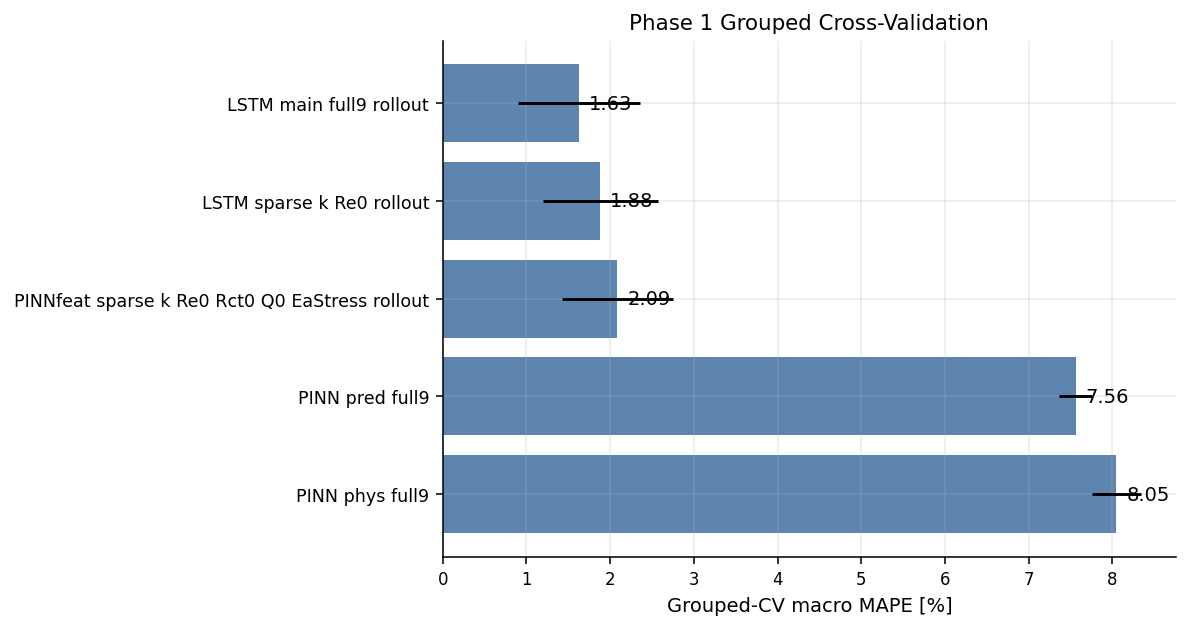

Saved: /kaggle/working/final_paper_results_synthesis_20260625_103238/figure_final_external_transfer_progression.png


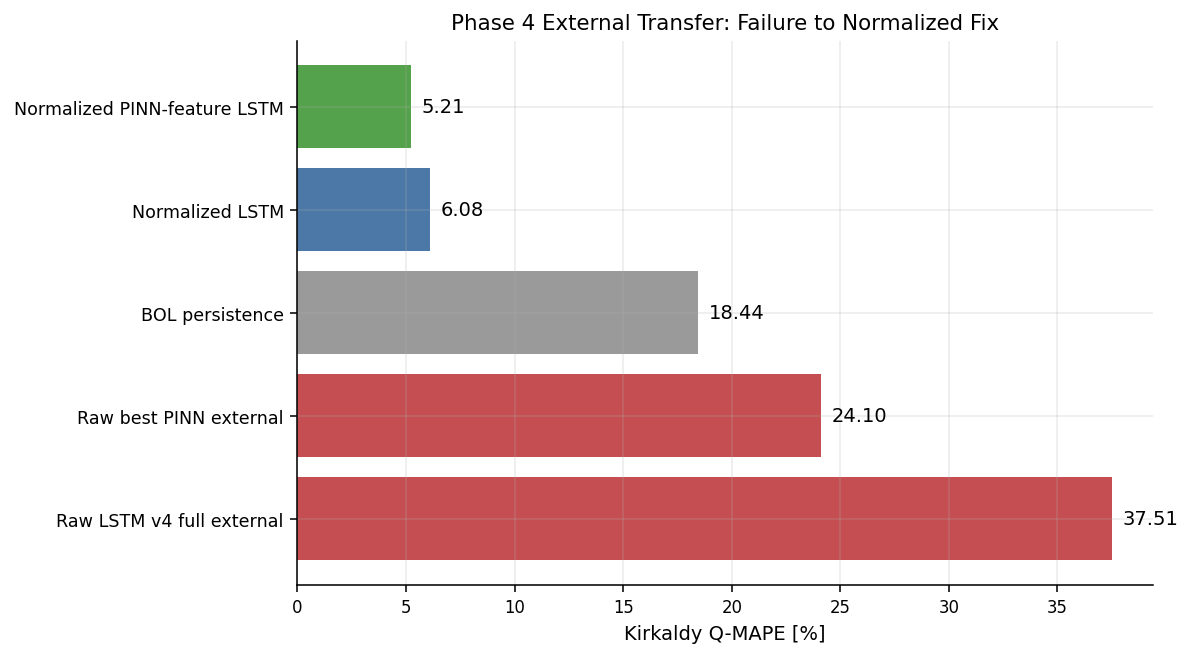

Saved: /kaggle/working/final_paper_results_synthesis_20260625_103238/figure_final_adaptation_success_conditions.png


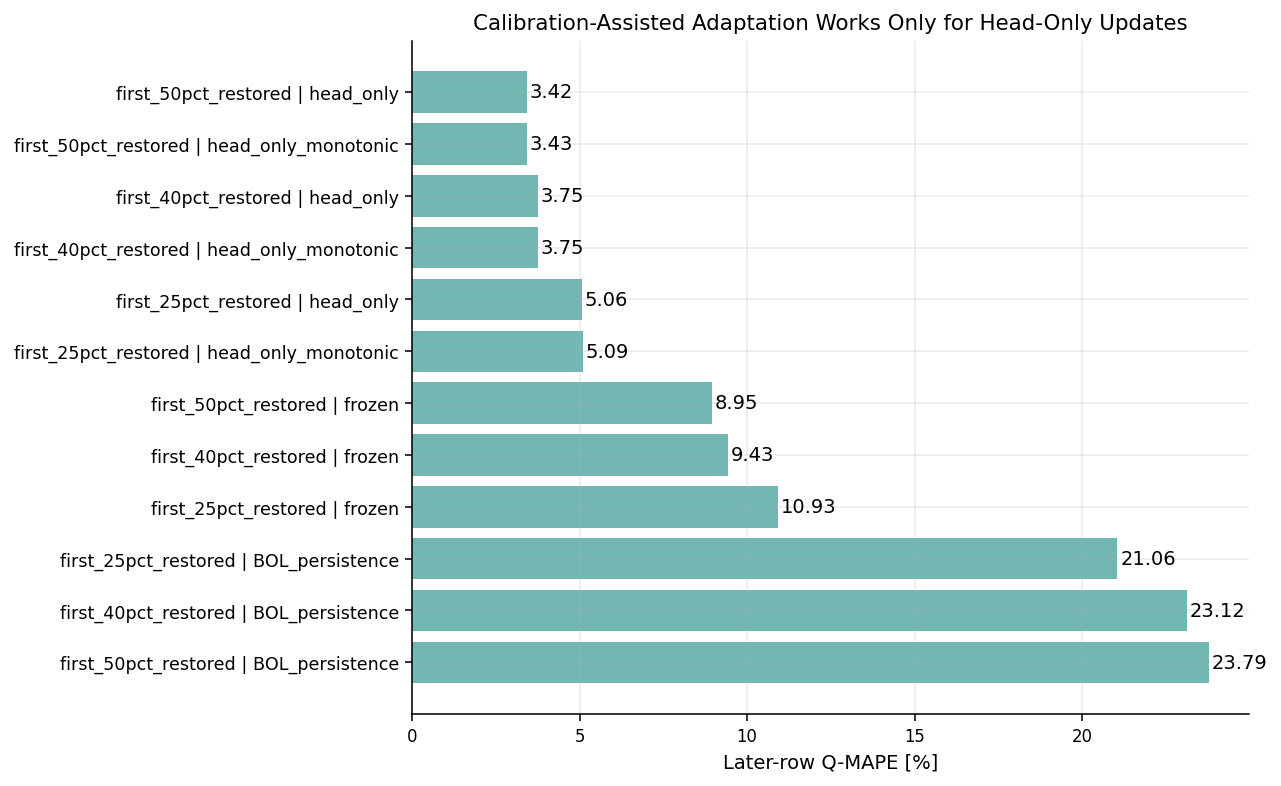

Saved: /kaggle/working/final_paper_results_synthesis_20260625_103238/figure_final_evidence_map.png


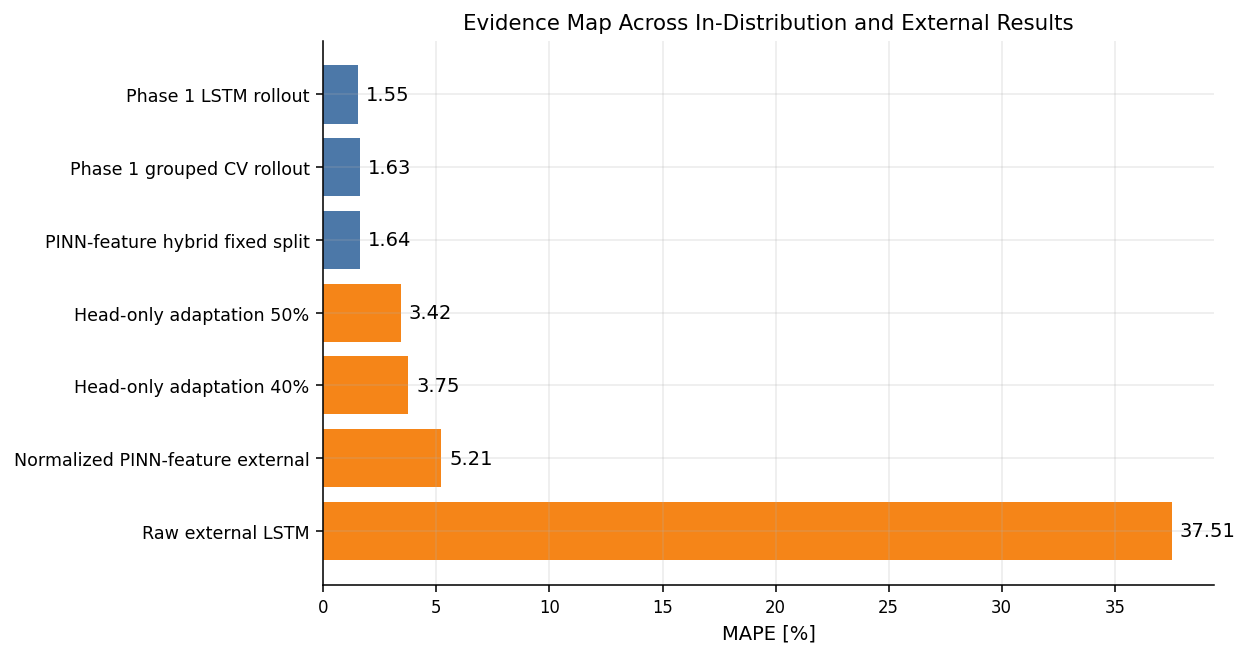

In [96]:
# Figure 1: Phase 1 key in-distribution results
fig, ax = plt.subplots(figsize=(8.6, 4.6))
plot_cv = phase1_cv.copy()
plot_cv = plot_cv[plot_cv["variant"].isin([
    "LSTM_main_full9_rollout",
    "LSTM_sparse_k_Re0_rollout",
    "PINNfeat_sparse_k_Re0_Rct0_Q0_EaStress_rollout",
    "PINN_pred_full9",
    "PINN_phys_full9",
])].copy()
plot_cv = plot_cv.sort_values("mean_MAPE")
labels = plot_cv["variant"].str.replace("_", " ", regex=False)
ax.barh(labels, plot_cv["mean_MAPE"], xerr=plot_cv.get("std_MAPE"), color="#4C78A8", alpha=0.9)
ax.invert_yaxis()
ax.set_xlabel("Grouped-CV macro MAPE [%]")
ax.set_title("Phase 1 Grouped Cross-Validation")
for i, v in enumerate(plot_cv["mean_MAPE"]):
    ax.text(v + 0.12, i, f"{v:.2f}", va="center")
ax.grid(axis="x", alpha=0.25)
savefig("figure_final_phase1_grouped_cv.png")
plt.show()

# Figure 2: External transfer progression
fig, ax = plt.subplots(figsize=(8.6, 4.8))
plot = external_progress.sort_values("Q_MAPE", ascending=False)
colors = {
    "Failure": "#C44E52",
    "Baseline": "#9A9A9A",
    "Normalized": "#4C78A8",
    "Normalized hybrid": "#54A24B",
}
ax.barh(plot["Stage"], plot["Q_MAPE"], color=[colors[c] for c in plot["Category"]])
ax.set_xlabel("Kirkaldy Q-MAPE [%]")
ax.set_title("Phase 4 External Transfer: Failure to Normalized Fix")
for i, v in enumerate(plot["Q_MAPE"]):
    ax.text(v + 0.5, i, f"{v:.2f}", va="center")
ax.grid(axis="x", alpha=0.25)
savefig("figure_final_external_transfer_progression.png")
plt.show()

# Figure 3: Adaptation success conditions
adapt_plot = adapt_q[adapt_q["Model"].str.contains("head_only|frozen|BOL_persistence", regex=True, na=False)].copy()
adapt_plot = adapt_plot[adapt_plot["Protocol"].str.contains("first_25pct|first_40pct|first_50pct", regex=True, na=False)]
adapt_plot = adapt_plot.sort_values("MAPE").head(16)
fig, ax = plt.subplots(figsize=(9.2, max(4.5, 0.36 * len(adapt_plot) + 1.4)))
labels = adapt_plot["Protocol"] + " | " + adapt_plot["Model"].str.replace("NormSOH_PINNfeat_LSTM_", "", regex=False)
ax.barh(labels, adapt_plot["MAPE"], color="#72B7B2")
ax.invert_yaxis()
ax.set_xlabel("Later-row Q-MAPE [%]")
ax.set_title("Calibration-Assisted Adaptation Works Only for Head-Only Updates")
for i, v in enumerate(adapt_plot["MAPE"]):
    ax.text(v + 0.08, i, f"{v:.2f}", va="center")
ax.grid(axis="x", alpha=0.25)
savefig("figure_final_adaptation_success_conditions.png")
plt.show()

# Figure 4: Claims evidence map
evidence_map = pd.DataFrame([
    {"Evidence": "Phase 1 LSTM rollout", "MAPE": 1.551, "Domain": "Luh/Blank", "Type": "fixed split"},
    {"Evidence": "Phase 1 grouped CV rollout", "MAPE": 1.626968, "Domain": "Luh/Blank", "Type": "grouped CV"},
    {"Evidence": "PINN-feature hybrid fixed split", "MAPE": 1.638201, "Domain": "Luh/Blank", "Type": "hybrid"},
    {"Evidence": "Raw external LSTM", "MAPE": 37.51, "Domain": "Kirkaldy", "Type": "raw external"},
    {"Evidence": "Normalized PINN-feature external", "MAPE": 5.206538, "Domain": "Kirkaldy", "Type": "zero-calibration"},
    {"Evidence": "Head-only adaptation 40%", "MAPE": 3.749086, "Domain": "Kirkaldy", "Type": "calibrated"},
    {"Evidence": "Head-only adaptation 50%", "MAPE": 3.418669, "Domain": "Kirkaldy", "Type": "calibrated"},
])
evidence_map.to_csv(OUT_DIR / "table_final_evidence_map.csv", index=False)

fig, ax = plt.subplots(figsize=(9.0, 4.8))
plot = evidence_map.sort_values("MAPE", ascending=False)
palette = {"Luh/Blank": "#4C78A8", "Kirkaldy": "#F58518"}
ax.barh(plot["Evidence"], plot["MAPE"], color=[palette[d] for d in plot["Domain"]])
ax.set_xlabel("MAPE [%]")
ax.set_title("Evidence Map Across In-Distribution and External Results")
for i, v in enumerate(plot["MAPE"]):
    ax.text(v + 0.35, i, f"{v:.2f}", va="center")
ax.grid(axis="x", alpha=0.25)
savefig("figure_final_evidence_map.png")
plt.show()


## 7. Export


In [97]:
manifest = {
    "run_tag": RUN_TAG,
    "sources": {
        "phase1_claims": src_phase1_claims,
        "phase1_cv": src_phase1_cv,
        "phase1_hybrid": src_phase1_hybrid,
        "phase4_raw": src_phase4_raw,
        "phase4d": src_phase4d,
        "phase4g": src_phase4g,
        "phase4e": src_phase4e,
        "phase4f": src_phase4f,
    },
    "outputs": sorted([p.name for p in OUT_DIR.iterdir()]),
}
(OUT_DIR / "final_synthesis_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

zip_path = WORKING / f"{RUN_TAG}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT_DIR.rglob("*")):
        if p.is_file():
            z.write(p, arcname=p.relative_to(OUT_DIR))

print_section("Done")
print("Output directory:", OUT_DIR)
print("Zip:", zip_path)
print("Files:")
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.name)



Done
Output directory: /kaggle/working/final_paper_results_synthesis_20260625_103238
Zip: /kaggle/working/final_paper_results_synthesis_20260625_103238.zip
Files:
 - figure_final_adaptation_success_conditions.png
 - figure_final_evidence_map.png
 - figure_final_external_transfer_progression.png
 - figure_final_phase1_grouped_cv.png
 - final_paper_claims.md
 - final_synthesis_manifest.json
 - table_final_adaptation_controls.csv
 - table_final_calibration_assisted_adaptation.csv
 - table_final_evidence_map.csv
 - table_final_external_progression.csv
 - table_final_main_results.csv
 - table_final_paper_claims.csv
